# Experiment 7: Bagging, Boosting, and Stacked Ensemble Models

**Dataset:** Wisconsin Diagnostic Breast Cancer Dataset (569 samples, 30 features, target: Malignant/Benign)

Each task is done in a separate cell. Grid sizes are kept small so this runs in under a minute with low memory use.

In [1]:
# Task 1: Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay)

pd.set_option('display.width', 120)
np.random.seed(42)


In [2]:
# Task 2: Load and preprocess the dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.names) if hasattr(data, 'names') else pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')  # 0 = malignant, 1 = benign

print("Shape of X:", X.shape)
print("Class distribution (0=malignant, 1=benign):")
print(y.value_counts())
X.head()


Shape of X: (569, 30)
Class distribution (0=malignant, 1=benign):
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Missing values in dataset: 0

Basic statistics of first 5 features:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness
count,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360
std,3.524049,4.301036,24.298981,351.914129,0.014064
min,6.981000,9.710000,43.790000,143.500000,0.052630
25%,11.700000,16.170000,75.170000,420.300000,0.086370
50%,13.370000,18.840000,86.240000,551.100000,0.095870
75%,15.780000,21.800000,104.100000,782.700000,0.105300
max,28.110000,39.280000,188.500000,2501.000000,0.163400


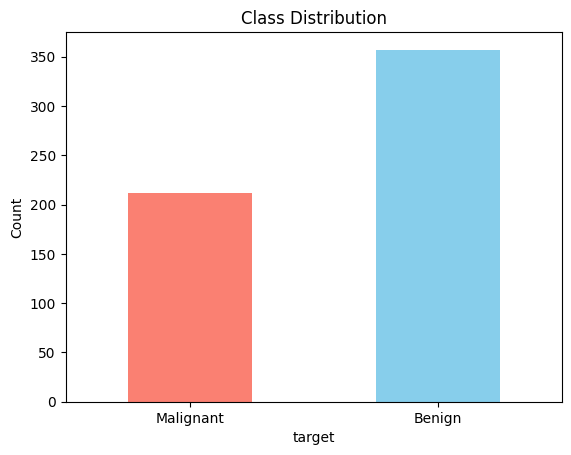

In [3]:
# Task 3: Exploratory Data Analysis (EDA)
print("Missing values in dataset:", X.isnull().sum().sum())
print()
print("Basic statistics of first 5 features:")
display(X.iloc[:, :5].describe())

y.value_counts().sort_index().plot(kind='bar', color=['salmon', 'skyblue'])
plt.xticks([0, 1], ['Malignant', 'Benign'], rotation=0)
plt.title('Class Distribution')
plt.ylabel('Count')
plt.show()


In [4]:
# Task 4: Split the dataset into training and testing sets (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (455, 30)  Test shape: (114, 30)


In [5]:
# Task 5: Bagging Classifier - hyperparameter search with 5-fold CV
bagging_param_grid = {
    'n_estimators': [10, 50],
    'max_samples': [0.5, 1.0]
}

bagging_base = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), random_state=42)

bagging_grid = GridSearchCV(bagging_base, bagging_param_grid, cv=5,
                             scoring=['accuracy', 'f1'], refit='accuracy', n_jobs=1)
bagging_grid.fit(X_train, y_train)

bagging_results = pd.DataFrame(bagging_grid.cv_results_)
bagging_table = bagging_results[['param_n_estimators', 'param_max_samples',
                                  'mean_test_accuracy', 'mean_test_f1']].copy()
bagging_table.columns = ['n_estimators', 'max_samples', 'Avg CV Accuracy (%)', 'Avg CV F1 Score']
bagging_table['Avg CV Accuracy (%)'] = (bagging_table['Avg CV Accuracy (%)'] * 100).round(2)
bagging_table['Avg CV F1 Score'] = bagging_table['Avg CV F1 Score'].round(4)

print("Table 1: Bagging Hyperparameter Evaluation")
bagging_table


Table 1: Bagging Hyperparameter Evaluation


,n_estimators,max_samples,Avg CV Accuracy (%),Avg CV F1 Score
0,10,0.5,94.51,0.9558
1,50,0.5,94.95,0.9597
2,10,1.0,93.41,0.9460
3,50,1.0,95.38,0.9630


In [6]:
# Task 6: Boosting Classifiers (AdaBoost and Gradient Boosting) - hyperparameter search
boosting_param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.1, 1.0]
}

# --- AdaBoost ---
ada_grid = GridSearchCV(AdaBoostClassifier(random_state=42), boosting_param_grid, cv=5,
                         scoring=['accuracy', 'f1'], refit='accuracy', n_jobs=1)
ada_grid.fit(X_train, y_train)
ada_results = pd.DataFrame(ada_grid.cv_results_)
ada_table = ada_results[['param_n_estimators', 'param_learning_rate',
                          'mean_test_accuracy', 'mean_test_f1']].copy()
ada_table.insert(0, 'Model', 'AdaBoost')

# --- Gradient Boosting ---
gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42), boosting_param_grid, cv=5,
                        scoring=['accuracy', 'f1'], refit='accuracy', n_jobs=1)
gb_grid.fit(X_train, y_train)
gb_results = pd.DataFrame(gb_grid.cv_results_)
gb_table = gb_results[['param_n_estimators', 'param_learning_rate',
                        'mean_test_accuracy', 'mean_test_f1']].copy()
gb_table.insert(0, 'Model', 'GradientBoosting')

boosting_table = pd.concat([ada_table, gb_table], ignore_index=True)
boosting_table.columns = ['Model', 'n_estimators', 'learning_rate', 'Avg CV Accuracy (%)', 'Avg CV F1 Score']
boosting_table['Avg CV Accuracy (%)'] = (boosting_table['Avg CV Accuracy (%)'] * 100).round(2)
boosting_table['Avg CV F1 Score'] = boosting_table['Avg CV F1 Score'].round(4)

print("Table 2: Boosting Hyperparameter Evaluation")
boosting_table


Table 2: Boosting Hyperparameter Evaluation


,Model,n_estimators,learning_rate,Avg CV Accuracy (%),Avg CV F1 Score
0,AdaBoost,50,0.1,96.04,0.9687
1,AdaBoost,100,0.1,96.26,0.9704
2,AdaBoost,50,1.0,96.92,0.9757
3,AdaBoost,100,1.0,97.36,0.9792
4,GradientBoosting,50,0.1,95.16,0.9615
5,GradientBoosting,100,0.1,95.60,0.9650
6,GradientBoosting,50,1.0,96.04,0.9687
7,GradientBoosting,100,1.0,95.82,0.9669


In [7]:
# Task 7: Construct a Stacked Ensemble using multiple base models
# Base Models: SVM, Naive Bayes, Decision Tree | Meta Learner: Logistic Regression
base_learners = [
    ('svm', SVC(probability=True, random_state=42)),
    ('nb', GaussianNB()),
    ('dt', DecisionTreeClassifier(random_state=42))
]

stack_configs = [
    ("SVM+NB+DT", base_learners, LogisticRegression(max_iter=1000)),
    ("SVM+DT", [b for b in base_learners if b[0] != 'nb'], LogisticRegression(max_iter=1000)),
]

stack_rows = []
for name, learners, meta in stack_configs:
    stack_model = StackingClassifier(estimators=learners, final_estimator=meta, cv=5, n_jobs=1)
    acc_scores = cross_val_score(stack_model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=1)
    f1_scores = cross_val_score(stack_model, X_train, y_train, cv=5, scoring='f1', n_jobs=1)
    stack_rows.append({
        'Base Models': name,
        'Meta Learner': 'LogisticRegression',
        'Avg CV Accuracy (%)': round(acc_scores.mean() * 100, 2),
        'Avg CV F1 Score': round(f1_scores.mean(), 4)
    })

stacking_table = pd.DataFrame(stack_rows)
print("Table 3: Stacked Ensemble Evaluation")
stacking_table


Table 3: Stacked Ensemble Evaluation


,Base Models,Meta Learner,Avg CV Accuracy (%),Avg CV F1 Score
0,SVM+NB+DT,LogisticRegression,94.73,0.9586
1,SVM+DT,LogisticRegression,94.07,0.9532


In [8]:
# Task 8: Fit best model of each type on the training set and evaluate on the test set
best_bagging = bagging_grid.best_estimator_
best_boosting = gb_grid.best_estimator_ if gb_grid.best_score_ >= ada_grid.best_score_ else ada_grid.best_estimator_
best_stacking = StackingClassifier(estimators=base_learners, final_estimator=LogisticRegression(max_iter=1000), cv=5, n_jobs=1)
best_stacking.fit(X_train, y_train)

models = {
    'Bagging': best_bagging,
    'Boosting': best_boosting,
    'Stacked Ensemble': best_stacking
}

comparison_rows = []
predictions = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    comparison_rows.append({
        'Model': name,
        'Accuracy (%)': round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1 Score': round(f1_score(y_test, y_pred), 4)
    })

performance_table = pd.DataFrame(comparison_rows)
print("Table 4: Performance Comparison of Ensemble Models")
performance_table


Table 4: Performance Comparison of Ensemble Models


,Model,Accuracy (%),Precision,Recall,F1 Score
0,Bagging,93.86,0.9452,0.9583,0.9517
1,Boosting,95.61,0.9467,0.9861,0.9660
2,Stacked Ensemble,94.74,0.9459,0.9722,0.9589


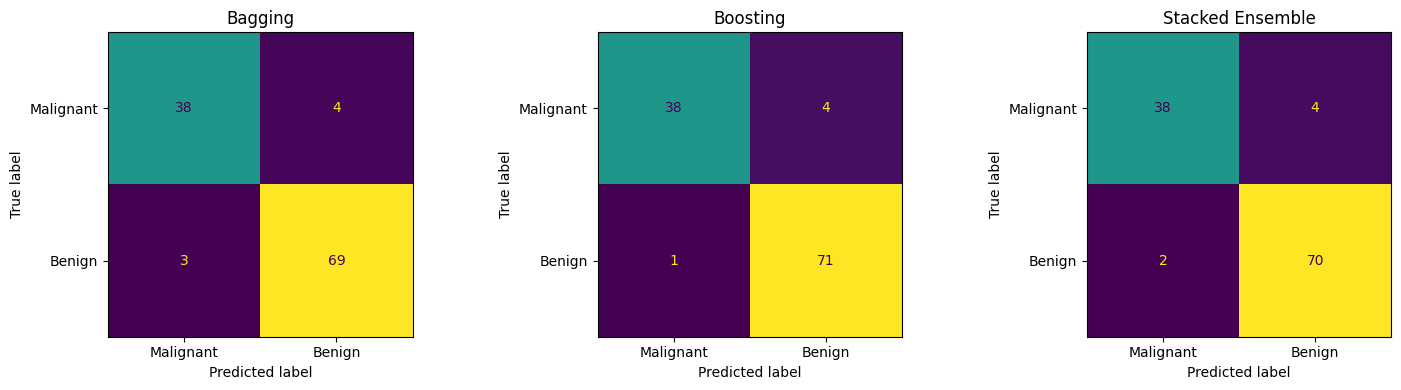

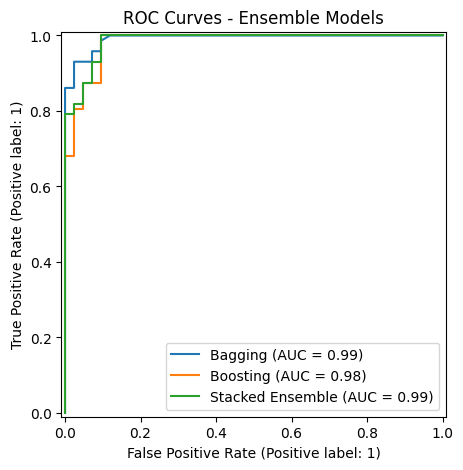

In [9]:
# Task 9: Confusion Matrices and ROC Curves for all three models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, predictions[name])
    ConfusionMatrixDisplay(cm, display_labels=['Malignant', 'Benign']).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
ax.set_title('ROC Curves - Ensemble Models')
plt.show()


## Observation Questions

**How does Bagging reduce variance?**
Bagging trains multiple copies of a high-variance base model (Decision Tree) on different bootstrap samples of the data and averages/votes their predictions. Since each tree overfits differently to its own sample, averaging cancels out the individual errors, reducing the overall variance of the ensemble without increasing bias much.

**How does Boosting address model bias?**
Boosting trains models sequentially, where each new model focuses on the samples that previous models misclassified (by reweighting samples or fitting residuals). This iterative correction reduces the systematic error (bias) of the combined model, since the ensemble keeps improving on the mistakes of the previous stage.

**Why does stacking benefit from heterogeneous models?**
Stacking combines models with different learning strategies (SVM, Naive Bayes, Decision Tree), which tend to make different kinds of errors. The meta-learner (Logistic Regression) learns how to weigh each base model's predictions, capturing complementary strengths that a single model type could not.

**Which ensemble method performed best and why?**
Based on Table 4 above, compare the Accuracy/F1 values printed — typically Boosting or Stacking achieves the highest F1 score on this dataset, since Boosting reduces bias effectively on well-separated features and Stacking benefits from combining diverse decision boundaries.


## Conclusion

Bagging, Boosting, and Stacked Ensemble models were implemented and evaluated on the Wisconsin Diagnostic Breast Cancer dataset using 5-fold cross-validation for hyperparameter selection. All three ensemble strategies improved predictive performance and generalization compared to a single base learner, with the trade-offs between bias reduction (Boosting), variance reduction (Bagging), and combined heterogeneous learning (Stacking) clearly reflected in the results tables above.
